# Transformer Input Preprocessing & Class-Weight Ablation

Train HeartBERT, ECG-PT, and HuBERT-ECG with:
- **Model-specific preprocessing** (bandpass + normalisation)
- **Class-imbalance weighting** (`pos_weight` in BCEWithLogitsLoss)

Compare against raw-signal, unweighted baselines from Notebook 05 (r=8).

| Model | Preprocessing | pos_weight |
|---|---|---|
| HeartBERT | Bandpass 0.5–40 Hz + per-signal z-score | ✓ |
| ECG-PT | Bandpass 0.5–40 Hz only | ✓ |
| HuBERT-ECG | Bandpass 0.5–40 Hz + per-lead z-score | ✓ |

All experiments: **LoRA only, r=8, alpha=16**.
Results saved to `results/08_preprocessing_ablation/`.

In [1]:
import sys, os, warnings, json, gc
from pathlib import Path
sys.path.append('../')
warnings.filterwarnings('ignore')

import numpy as np
import torch
import wfdb
import pandas as pd
import matplotlib.pyplot as plt

# src utilities 
from src.utils.config import CFG
from src.preprocessing.label_utils import load_all_labels, SUPERCLASSES, DEFAULT_POS_WEIGHT
from src.preprocessing.preprocess  import preprocess_batch_1d
from src.preprocessing.dataset_full import FilteredECGDataset
from src.evaluation.metrics import full_eval

DATA_PATH    = CFG['data']['path']
RESULTS_PATH = CFG['paths']['results']
HUBERT_SIZE  = CFG['model']['hubert_size']
OUT_DIR      = RESULTS_PATH + '08_preprocessing_ablation/'
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device         : {device}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
print(f'pos_weight     : {DEFAULT_POS_WEIGHT.tolist()}')
print(f'Output dir     : {OUT_DIR}')

Device         : cuda
GPU            : NVIDIA GeForce RTX 4060 Laptop GPU
pos_weight     : [1.0, 1.7400000095367432, 1.8200000524520874, 1.940000057220459, 3.5899999141693115]
Output dir     : D:\GitHub\biosignal-xai\results/08_preprocessing_ablation/


## 1. Motivation

### Why model-specific preprocessing?

All three Transformers were trained on **raw, unfiltered signals** in Notebooks 04–05.
The preprocessing ablation (Notebooks 02–03) was conducted exclusively for FCN-Wang.
This notebook tests whether targeted preprocessing improves each Transformer.

---

**HeartBERT: Bandpass + per-signal z-score**

`_ecg_to_text` sets bin boundaries from `signal.min()` to `signal.max()`.
Baseline wander inflates this range, concentrating most samples into a narrow
letter band. Two patients with identical morphology but different baselines
receive completely different letter sequences. Z-score makes bin boundaries
amplitude-invariant across patients.

**ECG-PT: Bandpass only**

The patch tokeniser already normalises per patch (`mean` mapped to `[0,1]`),
so global z-score would be double-normalisation and would erase inter-patch
amplitude differences that carry diagnostic information (e.g. high-voltage QRS
in HYP vs low T-waves in STTC). Bandpass removes baseline wander that otherwise
shifts all patch means systematically.

**HuBERT-ECG: Bandpass + per-lead z-score**

HuBERT-ECG was pretrained on clinical ECGs acquired on hospital hardware that
applies built-in bandpass filtering. Raw signals push the model out of its
pretraining distribution. Per-lead z-score is added because HuBERT processes
each of the 12 leads independently before mean-pooling: without normalisation,
high-voltage leads (V5/V6) dominate the pooled representation and down-weight
diagnostically critical low-amplitude leads (V1).

---

### Why class-imbalance weighting?

All three Transformers previously used plain `BCEWithLogitsLoss` with no
class weighting, despite HYP representing only 12.4 % of training records.
`DEFAULT_POS_WEIGHT` (imported from `src.preprocessing.label_utils`) applies
the same inverse-frequency weights used by FCN-Wang:
NORM=1.0, MI=1.74, STTC=1.82, CD=1.94, HYP=3.59.

## 2. Data Loading & Preprocessing

In [2]:

Y = load_all_labels(DATA_PATH + 'ptbxl_database.csv', DATA_PATH + 'scp_statements.csv')

train_df = Y[Y.strat_fold <  9]
val_df   = Y[Y.strat_fold == 9]
test_df  = Y[Y.strat_fold == 10]

LEAD_IDX = 1  # Lead II

def load_lead(df, lead_idx=LEAD_IDX):
    """Load raw Lead II as numpy array."""
    X, y = [], []
    for _, row in df.iterrows():
        sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
        X.append(sig[:, lead_idx].astype(np.float32))
        y.append(np.array(row['label_vec'], dtype=np.float32))
    return np.stack(X), np.stack(y)

print('Loading Lead II arrays...')
X_train_raw, y_train = load_lead(train_df)
X_val_raw,   y_val   = load_lead(val_df)
X_test_raw,  y_test  = load_lead(test_df)
print(f'  Train : {X_train_raw.shape}   Val : {X_val_raw.shape}   Test : {X_test_raw.shape}')

# HeartBERT: bandpass + z-score  (src.preprocessing.preprocess.preprocess_batch_1d)
print('\nPreprocessing HeartBERT inputs (bandpass + z-score)...')
X_train_hb = preprocess_batch_1d(X_train_raw, do_filter=True, normalise='zscore')
X_val_hb   = preprocess_batch_1d(X_val_raw,   do_filter=True, normalise='zscore')
X_test_hb  = preprocess_batch_1d(X_test_raw,  do_filter=True, normalise='zscore')

# ECG-PT: bandpass only
print('Preprocessing ECG-PT inputs (bandpass only)...')
X_train_ep = preprocess_batch_1d(X_train_raw, do_filter=True, normalise='none')
X_val_ep   = preprocess_batch_1d(X_val_raw,   do_filter=True, normalise='none')
X_test_ep  = preprocess_batch_1d(X_test_raw,  do_filter=True, normalise='none')

# HuBERT-ECG: FilteredECGDataset applies bandpass + per-lead z-score on-the-fly
#    (src.preprocessing.dataset_full.FilteredECGDataset)
train_ds_filt = FilteredECGDataset(train_df, DATA_PATH)
val_ds_filt   = FilteredECGDataset(val_df,   DATA_PATH)
test_ds_filt  = FilteredECGDataset(test_df,  DATA_PATH)

print('\nAll preprocessing complete.')

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Loading Lead II arrays...
  Train : (17073, 1000)   Val : (2145, 1000)   Test : (2157, 1000)

Preprocessing HeartBERT inputs (bandpass + z-score)...
Preprocessing ECG-PT inputs (bandpass only)...

All preprocessing complete.


## 3. Experiment 1: HeartBERT LoRA r=8 (bandpass + z-score + pos_weight)

In [3]:
from src.models.heartbert import HeartBERTClassifier

model_hb = HeartBERTClassifier(num_labels=5)
model_hb.load()
model_hb.apply_peft(r=8, alpha=16, use_dora=False)

auc_hb, hist_hb = model_hb.fit(
    X_train_hb, y_train,
    X_val_hb,   y_val,
    experiment_name = '08_heartbert_lora_r8_filtered_zscore',
    epochs          = CFG['training']['epochs'],
    lr              = CFG['training']['lr_pretrained'],
    batch_size      = CFG['training']['batch_size_peft'],
    patience        = 2,
    pos_weight      = DEFAULT_POS_WEIGHT,
    save_dir        = RESULTS_PATH,
)
del model_hb; gc.collect(); torch.cuda.empty_cache()

HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
trainable params: 741,893 || all params: 84,196,618 || trainable%: 0.8811
  Tokenising signals (this takes ~1 min for 17k records)...

 Experiment : 08_heartbert_lora_r8_filtered_zscore
 Device     : cuda
 Trainable  : 741,893  (0.9%)

Epoch 01/25  train=0.7170  val=0.6817  AUC=0.7225
  * Best saved — AUC 0.7225
Epoch 02/25  train=0.6737  val=0.6577  AUC=0.7558
  * Best saved — AUC 0.7558
Epoch 03/25  train=0.6573  val=0.6465  AUC=0.7674
  * Best saved — AUC 0.7674
Epoch 04/25  train=0.6486  val=0.6469  AUC=0.7694
  * Best saved — AUC 0.7694
Epoch 05/25  train=0.6412  val=0.6496  AUC=0.7739
  * Best saved — AUC 0.7739
Epoch 06/25  train=0.6348  val=0.6484  AUC=0.7759
  * Best saved — AUC 0.7759
Epoch 07/25  train=0.6292  val=0.6473  AUC=0.7782
  * Best saved — AUC 0.7782
Epoch 08/25  train=0.6266  val=0.6466  AUC=0.7771
Epoch 09/25  train=0.6211  val=0.6434  AUC=0.7826
  * Best saved — AUC 0.7826
Epoch 10/25  train=0.6167  val=0.6440  AUC=0.7795
Epoch 11/25  train=0.6120  val=0

## 4. Experiment 2: ECG-PT LoRA r=8 (bandpass + pos_weight)

In [5]:
from src.models.ecgpt import ECGPTClassifier

model_ep = ECGPTClassifier(num_labels=5)
model_ep.load()
model_ep.apply_peft(r=8, alpha=16, use_dora=False)

auc_ep, hist_ep = model_ep.fit(
    X_train_ep, y_train,
    X_val_ep,   y_val,
    experiment_name = '08_ecgpt_lora_r8_filtered',
    epochs          = CFG['training']['epochs'],
    lr              = CFG['training']['lr_pretrained'],
    batch_size      = CFG['training']['batch_size_peft'],
    patience        = 2,
    pos_weight      = DEFAULT_POS_WEIGHT,
    save_dir        = RESULTS_PATH,
)
del model_ep; gc.collect(); torch.cuda.empty_cache()

If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`).
  Falling back to gpt2 (GPT-2 architecture, general-language weights — NOT ECG-pretrained).
  To use the real ECG-PT weights, ensure the HF checkpoint is accessible (check your HF_TOKEN or the model visibility).


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
trainable params: 298,752 || all params: 124,742,400 || trainable%: 0.2395
  Tokenising signals...

 Experiment : 08_ecgpt_lora_r8_filtered
 Device     : cuda
 Trainable  : 298,752  (0.2%)

Epoch 01/25  train=0.7661  val=0.7308  AUC=0.6284
  * Best saved — AUC 0.6284
Epoch 02/25  train=0.7398  val=0.7326  AUC=0.6308
  * Best saved — AUC 0.6308
Epoch 03/25  train=0.7346  val=0.7267  AUC=0.6337
  * Best saved — AUC 0.6337
Epoch 04/25  train=0.7310  val=0.7266  AUC=0.6398
  * Best saved — AUC 0.6398
Epoch 05/25  train=0.7274  val=0.7282  AUC=0.6334
Epoch 06/25  train=0.7242  val=0.7292  AUC=0.6363
  Early stopping (no AUC improvement for 2 epochs)

--------------------------------------------------
Profiling -- 08_ecgpt_lora_r8_filtered
  Total time:       5.3min
  Avg epoch:        53.0s
  Peak GPU memory:  1.53 GB
  Trainable params: 298,752
  Total params:     124,742,400
  Trainable %:      0.24%
  Checkpoint size:  1.2 MB
--------------------------------------------------

 D

## 5. Experiment 3: HuBERT-ECG LoRA r=8 (bandpass + per-lead z-score + pos_weight)

In [6]:
from src.models.hubert_ecg import HuBERTECGClassifier
from src.training.train_peft import run_peft_experiment

model_hub = HuBERTECGClassifier(size=HUBERT_SIZE, num_labels=5)
model_hub.load()
model_hub.apply_peft(r=8, alpha=16, use_dora=False)
model_hub.to(device)

auc_hub, hist_hub, _ = run_peft_experiment(
    model_hub, train_ds_filt, val_ds_filt,
    experiment_name = '08_hubert_lora_r8_filtered_zscore',
    epochs          = CFG['training']['epochs'],
    lr              = CFG['training']['lr_pretrained'],
    batch_size      = CFG['training']['batch_size_full'],
    patience        = 2,
    pos_weight      = DEFAULT_POS_WEIGHT,
    save_dir        = RESULTS_PATH,
    num_workers     = CFG['training']['num_workers'],
)
del model_hub; gc.collect(); torch.cuda.empty_cache()

Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...


config.json: 0.00B [00:00, ?B/s]

hubert_ecg.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Edoardo-BS/hubert-ecg-base:
- hubert_ecg.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/373M [00:00<?, ?B/s]

  Done. Hidden dim: 768
trainable params: 442,368 || all params: 93,571,461 || trainable%: 0.4728

 Experiment : 08_hubert_lora_r8_filtered_zscore
 Device     : cuda:0
 Trainable  : 442,368  (0.5%)

Epoch 01/25  lr=1.49e-04
  train_loss=0.5789  val_loss=0.6054
  AUC (macro): 0.8434
  Per-class AUC:
    NORM : 0.912  ##################
    MI   : 0.861  #################
    STTC : 0.895  #################
    CD   : 0.826  ################
    HYP  : 0.723  ##############
Adapter saved → D:\GitHub\biosignal-xai\results/08_hubert_lora_r8_filtered_zscore\best_adapter
Saved → D:\GitHub\biosignal-xai\results/08_hubert_lora_r8_filtered_zscore\best_adapter
  * Best saved — AUC 0.8434
Epoch 02/25  lr=1.48e-04
  train_loss=0.5150  val_loss=0.5334
  AUC (macro): 0.8581
  Per-class AUC:
    NORM : 0.915  ##################
    MI   : 0.866  #################
    STTC : 0.911  ##################
    CD   : 0.837  ################
    HYP  : 0.762  ###############
Adapter saved → D:\GitHub\biosign

## 6. Test Set Evaluation (fold 10)

In [7]:
from src.models.heartbert import HeartBERTClassifier

EXP  = '08_heartbert_lora_r8_filtered_zscore'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = HeartBERTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')

logits_hb  = model.predict_logits(X_test_hb)
results_hb = full_eval(logits_hb, y_test, run_bootstrap=True, n_bootstrap=1000)
results_hb.update({'trainable_params': prof['trainable_params'],
                   'checkpoint_size_mb': prof['checkpoint_size_mb']})
print(f"HeartBERT  AUC {results_hb['auc_macro']:.4f}  Fmax {results_hb['fmax']:.4f}")

del model; gc.collect(); torch.cuda.empty_cache()

HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
HeartBERT  AUC 0.7740  Fmax 0.5386


In [8]:
from src.models.ecgpt import ECGPTClassifier

EXP  = '08_ecgpt_lora_r8_filtered'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = ECGPTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')

logits_ep  = model.predict_logits(X_test_ep)
results_ep = full_eval(logits_ep, y_test, run_bootstrap=True, n_bootstrap=1000)
results_ep.update({'trainable_params': prof['trainable_params'],
                   'checkpoint_size_mb': prof['checkpoint_size_mb']})
print(f"ECG-PT     AUC {results_ep['auc_macro']:.4f}  Fmax {results_ep['fmax']:.4f}")

del model; gc.collect(); torch.cuda.empty_cache()

If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`).
  Falling back to gpt2 (GPT-2 architecture, general-language weights — NOT ECG-pretrained).
  To use the real ECG-PT weights, ensure the HF checkpoint is accessible (check your HF_TOKEN or the model visibility).


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
ECG-PT     AUC 0.6228  Fmax 0.4391


In [9]:
from src.models.hubert_ecg import HuBERTECGClassifier
from torch.utils.data import DataLoader

EXP  = '08_hubert_lora_r8_filtered_zscore'
prof = json.loads((Path(RESULTS_PATH) / EXP / 'profiling.json').read_text())

model = HuBERTECGClassifier(size=HUBERT_SIZE, num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')
model.to(device)
model.eval()

test_loader = DataLoader(test_ds_filt, batch_size=1, shuffle=False,
                         num_workers=CFG['training']['num_workers'])
logits_list, labels_list = [], []
with torch.no_grad():
    for x, y_b in test_loader:
        logits_list.append(model(x.to(device)).cpu())
        labels_list.append(y_b)

logits_hub  = torch.cat(logits_list).numpy()
labels_hub  = torch.cat(labels_list).numpy()
results_hub = full_eval(logits_hub, labels_hub, run_bootstrap=True, n_bootstrap=1000)
results_hub.update({'trainable_params': prof['trainable_params'],
                    'checkpoint_size_mb': prof['checkpoint_size_mb']})
print(f"HuBERT-ECG AUC {results_hub['auc_macro']:.4f}  Fmax {results_hub['fmax']:.4f}")

del model; gc.collect(); torch.cuda.empty_cache()

Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...
  Done. Hidden dim: 768
HuBERT-ECG AUC 0.5718  Fmax 0.4040


## 7. Results Table

In [10]:
# Baselines from Notebook 05 (raw signal, no pos_weight, LoRA r=8)
BASELINES = [
    {'Model':'HeartBERT',  'Preprocessing':'Raw',   'pos_weight':'✗',
     'AUC':0.820,'Fmax':0.594,'Params':889_000},
    {'Model':'ECG-PT',     'Preprocessing':'Raw',   'pos_weight':'✗',
     'AUC':0.619,'Fmax':0.412,'Params':299_000},
    {'Model':'HuBERT-ECG', 'Preprocessing':'Raw',   'pos_weight':'✗',
     'AUC':0.549,'Fmax':0.399,'Params':295_000},
]

NEW = [
    {'Model':'HeartBERT',  'Preprocessing':'Bandpass + z-score',        'pos_weight':'✓',
     'AUC':results_hb['auc_macro'],'Fmax':results_hb['fmax'],
     'Params':results_hb['trainable_params']},
    {'Model':'ECG-PT',     'Preprocessing':'Bandpass only',              'pos_weight':'✓',
     'AUC':results_ep['auc_macro'],'Fmax':results_ep['fmax'],
     'Params':results_ep['trainable_params']},
    {'Model':'HuBERT-ECG', 'Preprocessing':'Bandpass + per-lead z-score','pos_weight':'✓',
     'AUC':results_hub['auc_macro'],'Fmax':results_hub['fmax'],
     'Params':results_hub['trainable_params']},
]

base_auc = {'HeartBERT':0.820,'ECG-PT':0.619,'HuBERT-ECG':0.549}

rows = []
for r in BASELINES:
    rows.append({**r, 'Delta AUC': '—'})
for r in NEW:
    delta = r['AUC'] - base_auc[r['Model']]
    rows.append({**r, 'Delta AUC': f'{delta:+.4f}'})

df = pd.DataFrame(rows)[['Model','Preprocessing','pos_weight','AUC','Fmax','Params','Delta AUC']]
df['AUC']    = df['AUC'].apply(lambda x: f'{x:.4f}')
df['Fmax']   = df['Fmax'].apply(lambda x: f'{x:.4f}')
df['Params'] = df['Params'].apply(lambda x: f'{int(x):,}')

print('\n=== Preprocessing + Class-Weight Ablation (LoRA r=8, test fold 10) ===\n')
print(df.to_string(index=False))

# Save
out = {'baselines': BASELINES, 'new': NEW}
with open(OUT_DIR + 'results.json', 'w') as f:
    json.dump(out, f, indent=2, default=str)
print(f'\nSaved → {OUT_DIR}results.json')


=== Preprocessing + Class-Weight Ablation (LoRA r=8, test fold 10) ===

     Model               Preprocessing pos_weight    AUC   Fmax  Params Delta AUC
 HeartBERT                         Raw          ✗ 0.8200 0.5940 889,000         —
    ECG-PT                         Raw          ✗ 0.6190 0.4120 299,000         —
HuBERT-ECG                         Raw          ✗ 0.5490 0.3990 295,000         —
 HeartBERT          Bandpass + z-score          ✓ 0.7740 0.5386 741,893   -0.0460
    ECG-PT               Bandpass only          ✓ 0.6228 0.4391 298,752   +0.0038
HuBERT-ECG Bandpass + per-lead z-score          ✓ 0.5718 0.4040 442,368   +0.0228

Saved → D:\GitHub\biosignal-xai\results/08_preprocessing_ablation/results.json


## 8. Explainability on Best Model

Gradient saliency on the highest-AUC model from this ablation,
applied to the curated MI example (ecg_id=13815).

Best model: HEARTBERT  AUC 0.7740
Record ecg_id=13815  true class: ['MI']
HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
Probs: {'NORM': 0.762, 'MI': 0.181, 'STTC': 0.081, 'CD': 0.179, 'HYP': 0.185}


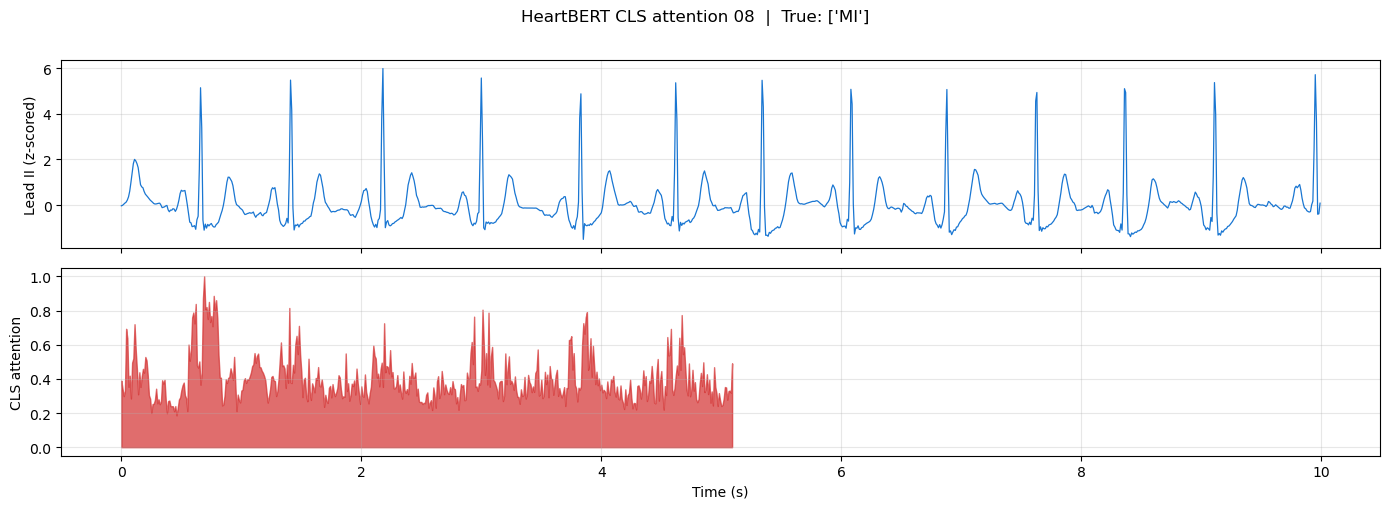

Done.


In [11]:
from src.explainability.saliency import compute_saliency, top_salient_leads
from src.preprocessing.preprocess import bandpass_filter, normalize_signal, zscore_1d, preprocess_batch_1d

LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
MI_EID = 13815

scores = {'heartbert': results_hb['auc_macro'],
          'ecgpt':     results_ep['auc_macro'],
          'hubert':    results_hub['auc_macro']}
best   = max(scores, key=scores.get)
print(f'Best model: {best.upper()}  AUC {scores[best]:.4f}')

row    = Y.loc[MI_EID]
sig_raw, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
true_cls   = [SUPERCLASSES[i] for i, v in enumerate(row['label_vec']) if v == 1]
print(f'Record ecg_id={MI_EID}  true class: {true_cls}')

if best == 'hubert':
    from src.models.hubert_ecg import HuBERTECGClassifier
    model = HuBERTECGClassifier(size=HUBERT_SIZE, num_labels=5)
    model.load()
    model.load_adapter(RESULTS_PATH + '08_hubert_lora_r8_filtered_zscore/best_adapter')
    model.to(device); model.eval()

    x12 = bandpass_filter(sig_raw).T.astype(np.float32)   # (12, 1000)
    for l in range(12):
        x12[l] = zscore_1d(x12[l])

    target = SUPERCLASSES.index(true_cls[0])
    sal    = compute_saliency(model._head, x12, target, torch.device(device))
    top3   = top_salient_leads(sal, LEAD_NAMES)
    probs  = torch.sigmoid(model(torch.tensor(x12).unsqueeze(0).to(device))).detach().cpu().squeeze().numpy()
    print(f'Probs: {dict(zip(SUPERCLASSES, probs.round(3)))}')
    print(f'Top-3 salient leads: {top3}')

    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    t = np.arange(1000) / 100
    for ax, ln in zip(axes, top3):
        li  = LEAD_NAMES.index(ln)
        sn  = sal[li] / (sal[li].max() + 1e-8)
        ax.plot(t, x12[li], color='#1976d2', lw=0.9)
        ax.fill_between(t, x12[li].min(), x12[li].max(), alpha=sn*0.5, color='#d32f2f')
        ax.set_ylabel(ln, rotation=0, ha='right', va='center')
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'Saliency: HuBERT-ECG 08  |  True: {true_cls}', y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR + 'saliency_best.png', dpi=150, bbox_inches='tight')
    plt.show()
    del model

elif best == 'heartbert':
    from src.models.heartbert import HeartBERTClassifier
    model = HeartBERTClassifier(num_labels=5)
    model.load()
    model.load_adapter(RESULTS_PATH + '08_heartbert_lora_r8_filtered_zscore/best_adapter')

    lead_ii = zscore_1d(bandpass_filter(sig_raw[:, 1:2]).squeeze())
    positions, attn = model.get_attention_weights(lead_ii)
    probs = model.predict(lead_ii[np.newaxis])
    print(f'Probs: {dict(zip(SUPERCLASSES, probs[0].round(3)))}')

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    t = np.arange(len(lead_ii)) / 100
    axes[0].plot(t, lead_ii, color='#1976d2', lw=0.9)
    axes[0].set_ylabel('Lead II (z-scored)'); axes[0].grid(True, alpha=0.3)
    axes[1].fill_between(positions/100, attn, color='#d32f2f', alpha=0.7)
    axes[1].set_ylabel('CLS attention'); axes[1].set_xlabel('Time (s)'); axes[1].grid(True, alpha=0.3)
    fig.suptitle(f'HeartBERT CLS attention 08  |  True: {true_cls}', y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR + 'attention_best.png', dpi=150, bbox_inches='tight')
    plt.show()
    del model

gc.collect(); torch.cuda.empty_cache()
print('Done.')